# PyFC: Checkpointing and Resuming an Interrupted Run

Feldman-Cousins calculations are resource-intensive and often run on shared HPC clusters
subject to walltime limits -- a Slurm job that hits its time limit gets `SIGKILL`ed mid-run,
with no chance to save anything on its own. `compute_fc_intervals`'s `warm_start` mechanism
(on by default) handles this transparently: it writes its accumulated state to
`checkpoint_fc.npz` inside `save_directory` after each meaningful unit of work completes,
and on the *next* call with the same `grids`, it loads that state and skips everything
already done instead of starting over.

**Checkpoint granularity** -- state is saved after: the one-time global unconditional fit,
each parameter's *complete* 1D scan, and each pair's *complete* 2D scan. If a run is killed
partway through a parameter's scan, that whole parameter's scan restarts on resume -- there
is no finer-grained (e.g. per-grid-point) checkpointing.

This notebook doesn't just describe the mechanism -- it actually kills a real, running
`compute_fc_intervals` call partway through (mimicking a Slurm walltime kill or a laptop
going to sleep) and shows resuming it correctly, faster than a fresh run, with the same
underlying result.


In [1]:
import multiprocessing
import os
import shutil
import time

import numpy as np
from numba import njit

from pyfc import compute_fc_intervals

np.random.seed(20260727)

REFERENCE_DIR = "checkpointing_output/reference"
INTERRUPTED_DIR = "checkpointing_output/interrupted_then_resumed"

# A 3-parameter binned model -- deliberately >= 2 parameters, since the point of
# this notebook is to interrupt the run *between* two parameters' 1D scans.
S_template = np.array([0.1, 0.5, 2.0, 5.0])
B_template = np.array([15.0, 5.0, 1.0, 0.1])
observed_counts = np.array([20, 7, 2, 0])
ZERO_SUMW2 = np.zeros_like(observed_counts).astype(float)


@njit(fastmath=True, nogil=True)
def compute_rates(params, S_sumw2, B_sumw2):
    # params[0] = S_norm, params[1] = B_norm, params[2] = sys_1 (flat shift)
    mu = params[0] * S_template + params[1] * B_template + params[2] * 0.05
    return mu, np.zeros_like(mu)


grids = [np.linspace(0.5, 1.5, 10) for _ in range(3)]
param_names = ["S_norm", "B_norm", "sys_1"]
N_TOYS = 60


def run_analysis(save_directory, warm_start, verbose=0):
    """Top-level (picklable/fork-safe) helper -- the same call, used for the
    reference run, the interrupted run, and the resumed run alike."""
    return compute_fc_intervals(
        data=observed_counts, grids=grids, compute_rates_func=compute_rates,
        S_sumw2=ZERO_SUMW2, B_sumw2=ZERO_SUMW2,
        cl=[0.90], n_toys=N_TOYS, strategy="scipy", num_cores=2, verbose=verbose,
        compute_1D_intervals=True, compute_2D_intervals=False,
        sparsify_grid=False, warm_start=warm_start,
        param_names=param_names,
        save_directory=save_directory,
    )


# Start from a clean slate so this notebook behaves the same on every re-run
# (not something you'd do with a real interrupted analysis -- there, the whole
# point is that the checkpoint from your *previous* crashed run is still there).
shutil.rmtree(REFERENCE_DIR, ignore_errors=True)
shutil.rmtree(INTERRUPTED_DIR, ignore_errors=True)

Numba detected: JIT compilation enabled for maximum speed.


## 1. Calibration: how long does an uninterrupted run take?

We need this timing to know *when* to interrupt the next run -- partway through parameter 2's
scan, after parameter 1's is already checkpointed. This reference run also gives us a
known-correct result to compare the interrupted-and-resumed run against later.

Full, uninterrupted run: 10.21s
Reference best fit: [0.5        1.31600912 0.5       ]


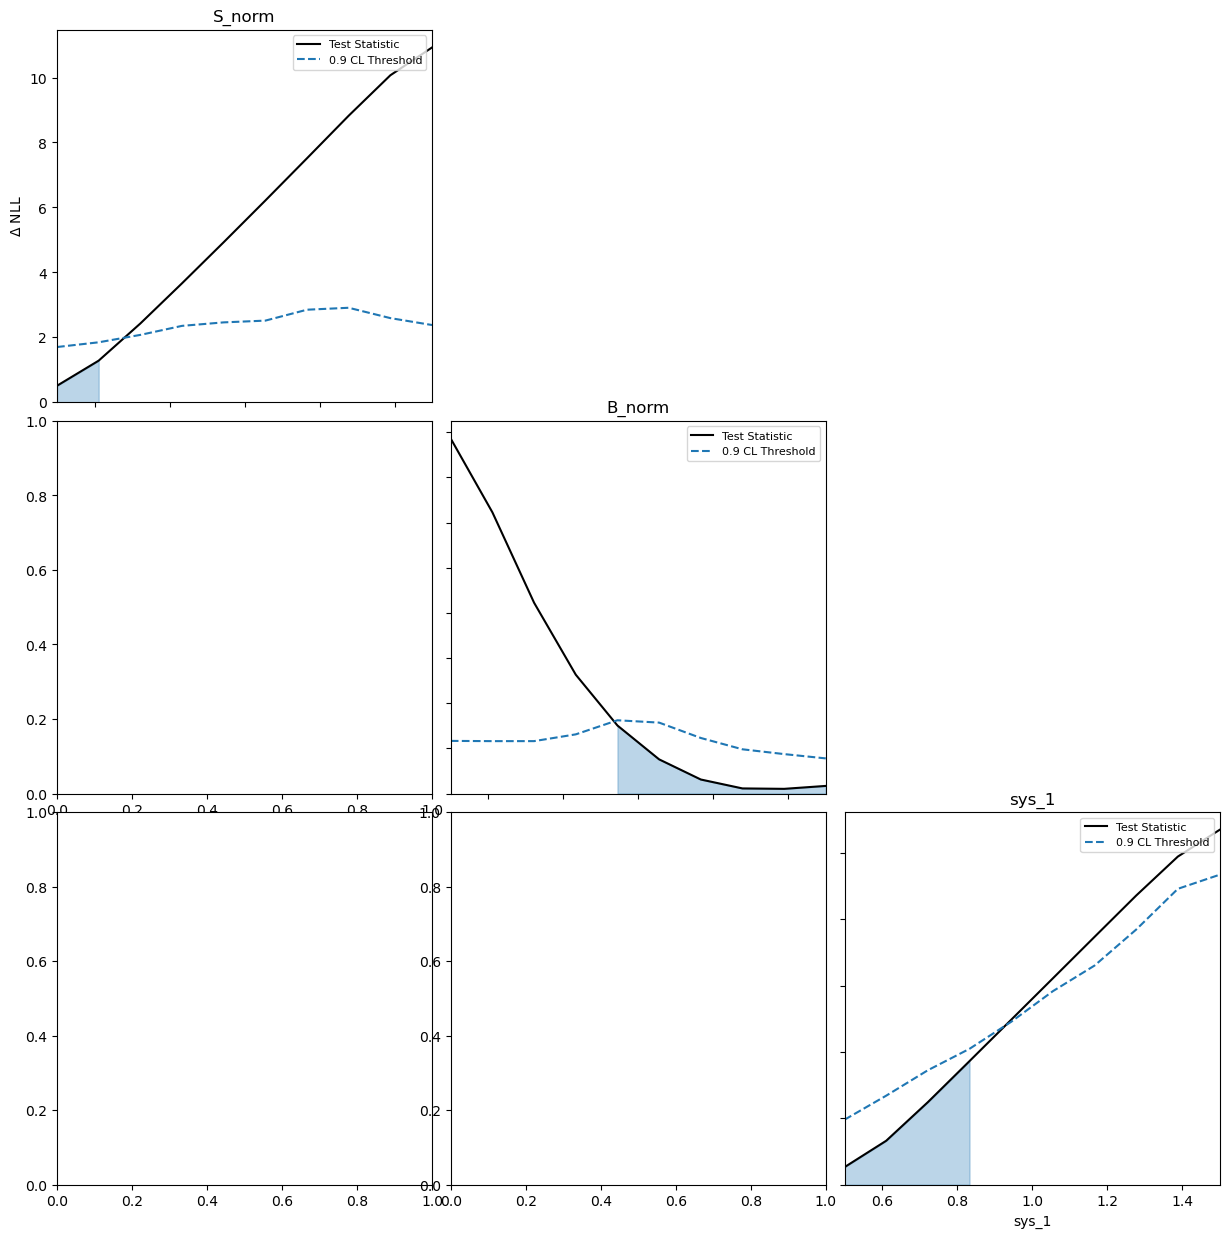

In [2]:
t0 = time.time()
results_reference, _ = run_analysis(REFERENCE_DIR, warm_start=False)
t_full = time.time() - t0

print(f"Full, uninterrupted run: {t_full:.2f}s")
print("Reference best fit:", results_reference["best_fit"])

## 2. Simulating an interruption

We launch the *same* analysis in a real child process via `multiprocessing.Process`, let it
run for a fraction of the calibrated full-run time (long enough that parameter 1's scan has
definitely finished and checkpointed, short enough that parameters 2 and 3 haven't started),
then call `.terminate()` -- which sends `SIGTERM`, the same signal a Slurm job gets when it
hits its walltime. This is a genuine kill of a genuinely-running computation, not a simulated
one.

In [3]:
proc = multiprocessing.Process(target=run_analysis, args=(INTERRUPTED_DIR, True))
proc.start()

kill_after = t_full * 0.45   # comfortably past parameter 1, comfortably before parameter 3
time.sleep(kill_after)
proc.terminate()
proc.join()

print(f"Killed the analysis process after {kill_after:.2f}s "
      f"(exit code {proc.exitcode}, negative = terminated by signal)")

Killed the analysis process after 4.59s (exit code -15, negative = terminated by signal)


In [4]:
# Inspect the checkpoint left behind -- proof this was a genuine partial state,
# not a completed run.
ckpt_path = os.path.join(INTERRUPTED_DIR, "checkpoint_fc.npz")
print("checkpoint_fc.npz exists:", os.path.exists(ckpt_path))

ckpt = np.load(ckpt_path)
for p_idx in range(3):
    key = f"1d_t_data_p{p_idx + 1}"
    n_done = int(np.sum(~np.isnan(ckpt[key])))
    print(f"  {param_names[p_idx]}: {n_done}/{len(ckpt[key])} grid points computed")

checkpoint_fc.npz exists: True
  S_norm: 10/10 grid points computed
  B_norm: 0/10 grid points computed
  sys_1: 0/10 grid points computed


Parameter 1 should show all grid points computed, and at least one of parameters 2/3 should
show zero -- a real mid-run interruption, not a lucky full completion. (If parameter 1 isn't
fully done, or all three parameters are, the machine running this notebook is faster/slower
than expected -- rerun this section, or adjust the `0.45` fraction above.)

## 3. Resuming

Just call `compute_fc_intervals` again with the identical `grids` and `warm_start=True` on the
same `save_directory` -- there is no separate "resume" API. PyFC detects the checkpoint,
verifies the grids match exactly, and picks up where the killed process left off.

Resumed run: 6.26s (vs. 10.21s for the fresh, uninterrupted run)
Checkpoint file cleaned up after completion: True


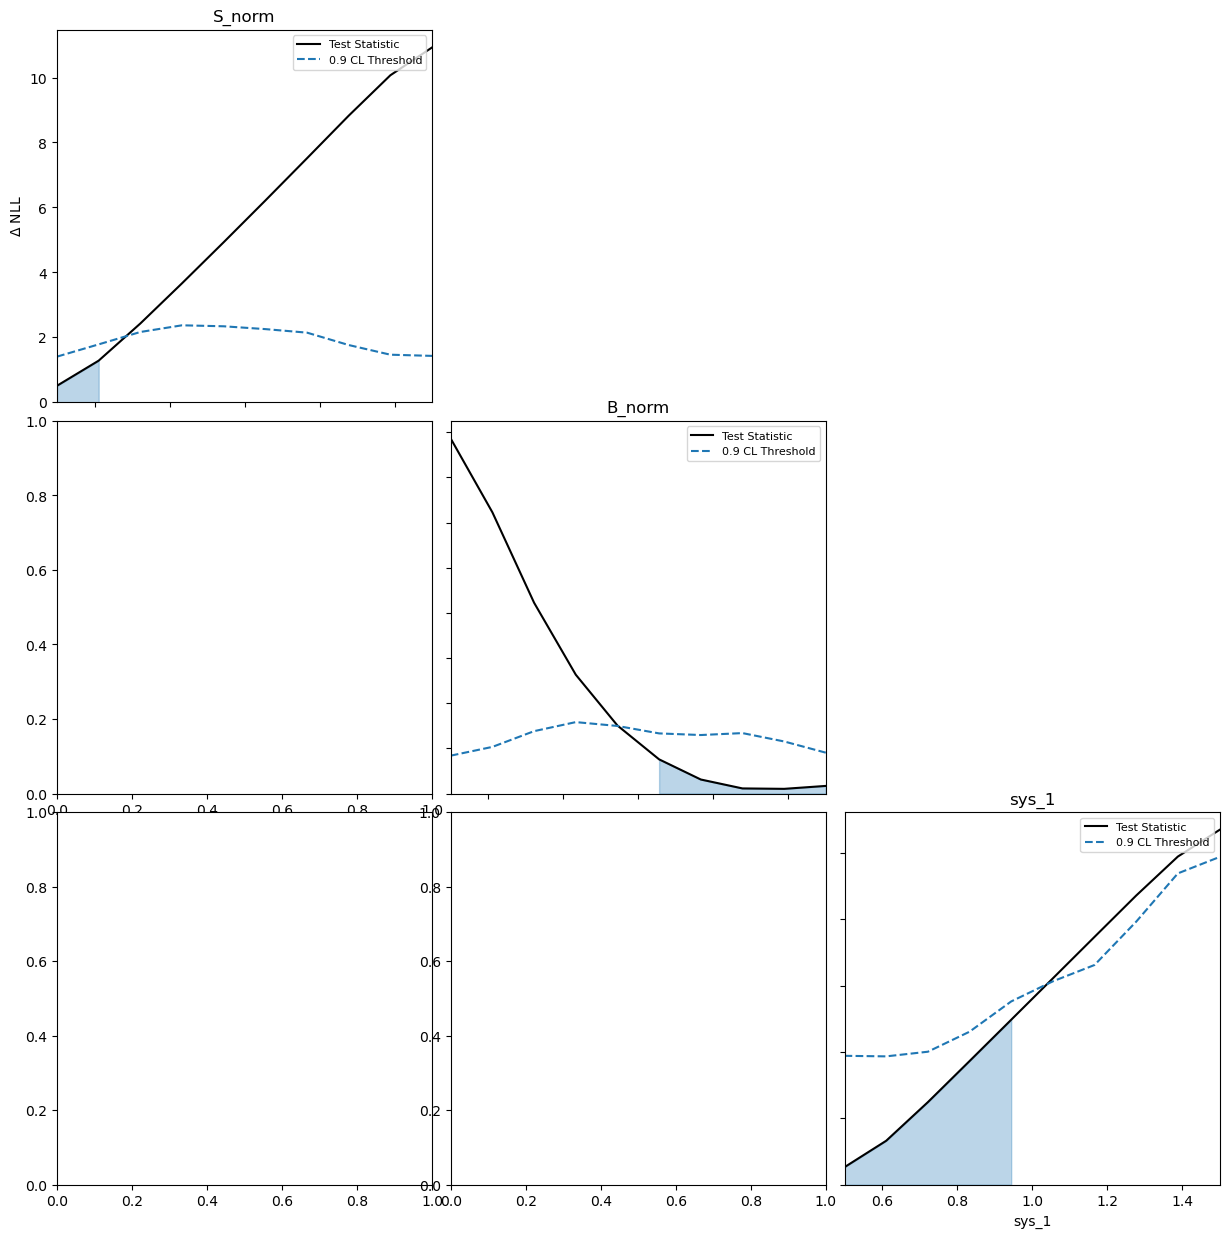

In [5]:
t0 = time.time()
results_resumed, _ = run_analysis(INTERRUPTED_DIR, warm_start=True)
t_resume = time.time() - t0

print(f"Resumed run: {t_resume:.2f}s (vs. {t_full:.2f}s for the fresh, uninterrupted run)")
print(f"Checkpoint file cleaned up after completion: {not os.path.exists(ckpt_path)}")

The resumed run should take noticeably less time than the fresh run -- parameter 1's fits and
toys were loaded from the checkpoint, not recomputed.

For a correctness check that isn't just "it finished": `1d_t_data_p1` (the profile-likelihood
data test statistic for parameter 1) is a **deterministic** quantity -- a fit to the fixed,
real observed data, with no Monte Carlo randomness involved. If parameter 1 was genuinely
reloaded from checkpoint rather than silently recomputed with some subtly different state, this
must match the reference run's value *exactly*.

In [6]:
np.testing.assert_array_equal(
    results_resumed["1d_t_data_p1"], results_reference["1d_t_data_p1"]
)
np.testing.assert_allclose(
    results_resumed["best_fit"], results_reference["best_fit"], rtol=1e-10
)
print("Parameter 1's data test statistic and the global best fit match the "
      "reference run exactly.")

print("\n1D 90% CL accepted bounds, reference vs. resumed:")
for p_idx in range(3):
    test_pts = results_reference[f"1d_test_p{p_idx + 1}"]
    for label, res in (("reference", results_reference), ("resumed  ", results_resumed)):
        acc = res[f"1d_accepted_p{p_idx + 1}"][0.90]
        pts = test_pts[acc]
        bounds = f"[{pts.min():.3g}, {pts.max():.3g}]" if len(pts) else "empty"
        print(f"  {param_names[p_idx]:>6} ({label}): {bounds}")

Parameter 1's data test statistic and the global best fit match the reference run exactly.

1D 90% CL accepted bounds, reference vs. resumed:
  S_norm (reference): [0.5, 0.611]
  S_norm (resumed  ): [0.5, 0.611]
  B_norm (reference): [0.944, 1.5]
  B_norm (resumed  ): [0.944, 1.5]
   sys_1 (reference): [0.5, 1.39]
   sys_1 (resumed  ): [0.5, 1.39]


Parameters 2 and 3's `t_critical` values come from freshly-generated Monte Carlo toys in both
runs (the reference run's toys and the resumed run's toys are two independent draws), so their
accepted bounds may wobble very slightly from MC noise at this `n_toys` -- that's expected, not
a bug. Parameter 1's bounds, reloaded byte-for-byte from the checkpoint, will always match
exactly.

## Critical restart warning

PyFC verifies that your `grids` match the checkpoint exactly before resuming, but it does
**not** verify anything else. If you abort a run and then change `n_toys`, `strategy`,
`likelihood_type`, or your `compute_rates_func`'s actual physics before resuming, PyFC will
still "successfully" resume -- silently merging structurally incompatible pseudo-experiment
results into your finalized thresholds. If you need to change any of those between an aborted
run and rerunning, **delete `checkpoint_fc.npz` from `save_directory` first** (this notebook's
own cleanup cell above does exactly that, via `shutil.rmtree`, before its "clean slate" runs).
Only `grids` itself is safe to trust the automatic verification for.

## Next steps

* `01_pyfc_quickstart_tutorial.ipynb` -- the basic binned/unbinned workflow, if you haven't
  started there yet.
* `05_pyfc_strategy_comparison_tutorial.ipynb` -- building custom plots directly from PyFC's
  saved `.json`/`.npz` output (the same files this notebook's checkpoints build towards).